# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [159]:
import math
# Imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
from statistics import mean

import scipy.special
from tqdm import tqdm
import shutil
from joblib import Parallel, delayed
from scipy.special import factorial
import powerlaw
from NEMtropy import UndirectedGraph


In [160]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_RED = 'lightcoral'
COLOR_GREY = 'slategrey'
COLOR_BLACK = 'black'
COLOR_LIGHT_GRAY = 'lightgray'
COLOR_DARK_GRAY = 'darkgray'

# Define the main data directory
OUTPUT_PATH = "./output"

In [161]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
OUTPUT_PATH_ER = os.path.join(OUTPUT_PATH, "erdos_renyi_avg_clustering")


# Recreate the subdirectories
os.makedirs(OUTPUT_PATH_ER)

In [162]:
# Define the directory containing the .gml files
directory = 'assignment_03_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files: 100%|██████████| 2/2 [00:00<00:00, 79.99it/s]


In [163]:
# Define the directory containing the .gml files
directory = 'assignment_03_data/World_Trade_Web'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.graphml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs_wtn = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML WTW Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()

            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.txt.graphml$', file_path)
            if match:
                graph_name = match.group(1)

                # Add to the graph dictionary
                graph = nx.read_graphml(file_path)
                graphs_wtn[graph_name] = graph

                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")

        pbar.update(1)  # Update the progress bar

Loading GML WTW Files:   9%|▉         | 1/11 [00:00<00:01,  7.14it/s]

Finished loading World_Trade_Web\WDN_1992


Loading GML WTW Files:  18%|█▊        | 2/11 [00:00<00:02,  4.01it/s]

Finished loading World_Trade_Web\WDN_1993
Finished loading World_Trade_Web\WDN_1994


Loading GML WTW Files:  36%|███▋      | 4/11 [00:00<00:01,  3.73it/s]

...

Finished loading World_Trade_Web\WDN_2000


Loading GML WTW Files:  91%|█████████ | 10/11 [00:03<00:00,  2.54it/s]

Finished loading World_Trade_Web\WDN_2001


Loading GML WTW Files: 100%|██████████| 11/11 [00:03<00:00,  2.96it/s]

Finished loading World_Trade_Web\WDN_2002


In [164]:

# Define the directory containing the .npy files
directory = 'assignment_03_data/NYSE'

# Use glob to get a list of all .npy files in the directory
npy_files = glob.glob(os.path.join(directory, '*.npy'))

# Init an empty dictionary for all arrays - the key is the actual name, and the value is the array data
arrays_nyse = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(npy_files), desc="Loading NPY Files") as pbar:
    # Loop through the list of .npy files and load them
    for file_path in npy_files:
        array_name = os.path.splitext(os.path.basename(file_path))[0]

        # Load the numpy array
        array_data = np.load(file_path)

        # Add to the array dictionary
        arrays_nyse[array_name] = array_data

        # Print the array name when each part is finished
        print(f"Finished loading {array_name}")

        pbar.update(1)  # Update the progress bar

# Get stocknames
stocks = np.loadtxt(directory+"/stocknames.txt", dtype=str)

Loading NPY Files: 100%|██████████| 6/6 [00:00<00:00, 103.44it/s]

Finished loading cormat_1h
Finished loading cormat_1m
Finished loading cormat_gaussian_1h
Finished loading cormat_gaussian_1m
Finished loading cormat_onefactor_1h
Finished loading cormat_onefactor_1m


# Stock correlations

## 1. Is there a market mode at the minute and hour timescale?
Hint: The existence of the market mode is related to the gap between the largest and second largest
eigenvalues of the correlation matrix.


In [165]:
# Load Data
arrays_nyse

{'cormat_1h': array([[ 1.        ,  0.16724079,  0.17792163, ...,  0.0185428 ,
         -0.04161977,  0.157766  ],
        [ 0.16724079,  1.        ,  0.46343185, ...,  0.28985369,
          0.20418909,  0.29171091],
        [ 0.17792163,  0.46343185,  1.        , ...,  0.39057488,
          0.24218336,  0.24357246],
        ...,
        [ 0.0185428 ,  0.28985369,  0.39057488, ...,  1.        ,
          0.42720044,  0.44063307],
        [-0.04161977,  0.20418909,  0.24218336, ...,  0.42720044,
          1.        ,  0.41781517],
        [ 0.157766  ,  0.29171091,  0.24357246, ...,  0.44063307,
          0.41781517,  1.        ]]),
 'cormat_1m': array([[1.        , 0.16174328, 0.29933708, ..., 0.21205377, 0.26330366,
         0.28766365],
        [0.16174328, 1.        , 0.2303112 , ..., 0.18402302, 0.23935938,
         0.35348702],
        [0.29933708, 0.2303112 , 1.        , ..., 0.2000015 , 0.27890206,
         0.29681243],
        ...,
        [0.21205377, 0.18402302, 0.2000015 , .

In [166]:
### NOT SURE IF A LOADED THE RIGHT DATA
cormat_1h = arrays_nyse["cormat_1h"]
cormat_1m = arrays_nyse["cormat_1m"]

# Calculate eigenvalues
eigenvalues_1h = np.linalg.eigvals(cormat_1h)
eigenvalues_1m = np.linalg.eigvals(cormat_1m)

# Sort eigenvalues in descending order
sorted_eigenvalues_1h = np.sort(eigenvalues_1h)[::-1]
sorted_eigenvalues_1m = np.sort(eigenvalues_1m)[::-1]

In [167]:
def getAllGapValues(sorted_eigenvalues):
    result = []
    for i in range(len(sorted_eigenvalues)-1):
        result.append(sorted_eigenvalues[i]-sorted_eigenvalues[i+1])
        
    return result


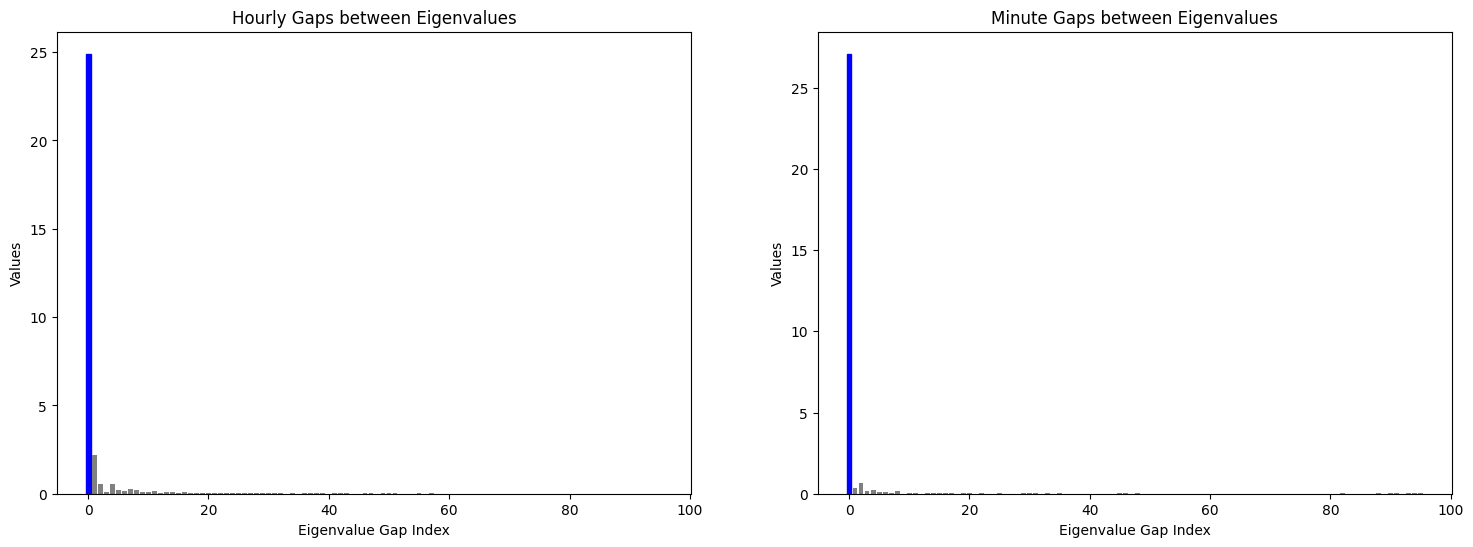

In [168]:
# Get all gaps
hourly_gaps = getAllGapValues(sorted_eigenvalues_1h)
min_gaps = getAllGapValues(sorted_eigenvalues_1m)

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Plot the hourly gaps in the first subplot
bars1 = axs[0].bar(range(len(hourly_gaps)), hourly_gaps, color='gray')  
bars1[0].set_color('blue')  
axs[0].set_xlabel('Eigenvalue Gap Index')
axs[0].set_ylabel('Values')
axs[0].set_title('Hourly Gaps between Eigenvalues')

# Plot the minute gaps in the second subplot
bars2 = axs[1].bar(range(len(min_gaps)), min_gaps, color='gray')  
bars2[0].set_color('blue')  
axs[1].set_xlabel('Eigenvalue Gap Index')
axs[1].set_ylabel('Values')
axs[1].set_title('Minute Gaps between Eigenvalues')

plt.show()

We can clearly see that the first gap is surpassing the others. This suggests the presence of a market mode at both the hour and minute timescales.

##  2. Compute the degree distributions of the 1 hour and 1 minute MSTs. Which are the 5 stocks with highest degree on the two different timescales MST?
Hint: To build the MST, use networkx.minimum_spanning_tree on the weighted undirected graph that is generated by the matrix with entries dij (see lecture on financial networks). 

Assign the correct ticker (AAPL, AMZN, ...) as an attribute to the nodes, by using 
`networkx.set_node_attributes(G, values=tickers, name=’ticker’)`



In [169]:
cormat_1h = arrays_nyse["cormat_1h"]
cormat_1m = arrays_nyse["cormat_1m"]
tickers_1h = stocks
tickers_1m = stocks

In [170]:
# Use MP to distinguish relevant signal from noise by identifying and removing noise components in the eigenvalues.
def denoise_mp(correlation_matrix, t, noise_constant=1):
    
    # As said sigma can be assumed to be 1
    sigma = 1 

    # Compute eigenvalues
    eigenvalues, eigenvectors = np.linalg.eig(correlation_matrix)

    # Determine the theoretical lamda_max
    #Q = len(correlation_matrix) / len(eigenvalues)
    Q = t / len(correlation_matrix)
    lambda_max = (sigma ** 2) * (1 + (1 / Q) + 2 * np.sqrt(1 / Q)) 

    # Any 𝜆 < 𝜆𝑚𝑎𝑥 is classified as noise, others are signal - Replace noise 𝜆s with a constant
    eigenvalues_denoised = np.where(eigenvalues < lambda_max, noise_constant, eigenvalues) 

    # Renormalize eigenvalues so that sum of all eigenvalues are the length of the array
    eigenvalues_denoised = eigenvalues_denoised / sum(eigenvalues_denoised) * len(eigenvalues_denoised)
    
    # Undo diagonalization to get denoised correlation matrix
    denoised_matrix = np.dot(eigenvectors, np.dot(np.diag(eigenvalues_denoised), np.linalg.inv(eigenvectors)))
    
    return denoised_matrix

In [171]:
cormat_1h_denoised = denoise_mp(cormat_1h, 22*6*60)
cormat_1m_denoised = denoise_mp(cormat_1m, 22*6*60)

num_assets_1h = len(cormat_1h_denoised)
num_assets_1m = len(cormat_1m_denoised)

# Initialize an empty distance matrix
distance_matrix_1h = np.zeros((num_assets_1h, num_assets_1h))
distance_matrix_1m = np.zeros((num_assets_1m, num_assets_1m))


# Compute the distance matrix based on the correlation coefficients
for i in range(num_assets_1h):
    for j in range(i + 1, num_assets_1h):
        correlation_coefficient = cormat_1h_denoised[i, j]
        distance_ij = np.sqrt(2 * (1 - correlation_coefficient))
        distance_matrix_1h[i, j] = distance_ij
        distance_matrix_1h[j, i] = distance_ij  # Since these values should be the same (symmetric). However we could only look on the left or right side from the diagonal

# Compute the distance matrix based on the correlation coefficients
for i in range(num_assets_1m):
    for j in range(i + 1, num_assets_1m):
        correlation_coefficient = cormat_1m_denoised[i, j]
        distance_ij = np.sqrt(2 * (1 - correlation_coefficient))
        distance_matrix_1m[i, j] = distance_ij
        distance_matrix_1m[j, i] = distance_ij  # Since these values should be the same (symmetric). However we could only look on the left or right side from the diagonal


In [172]:
# Prepare the graph data

# Create two weighted graphs
G_1h = nx.Graph()
G_1m = nx.Graph()

# Create a dictionary with tickers as both keys and values
tickers_dict_1h = {ticker: ticker for ticker in tickers_1h}
tickers_dict_1m = {ticker: ticker for ticker in tickers_1m}


# Add nodes to the graph
G_1h.add_nodes_from(tickers_1h)
G_1m.add_nodes_from(tickers_1m)

# Set 'ticker' attribute for each node
nx.set_node_attributes(G_1h, tickers_dict_1h, name='ticker')
nx.set_node_attributes(G_1m, tickers_dict_1m, name='ticker')

# Add weighted edges for G_1h
for i in range(len(tickers_1h)):
    for j in range(i + 1, len(tickers_1h)):
        weight_1h = distance_matrix_1h[i][j]
        G_1h.add_edge(tickers_1h[i], tickers_1h[j], weight=weight_1h)

# Add weighted edges for G_1m
for i in range(len(tickers_1m)):
    for j in range(i + 1, len(tickers_1m)):
        weight_1m = distance_matrix_1m[i][j]
        G_1m.add_edge(tickers_1m[i], tickers_1m[j], weight=weight_1m)


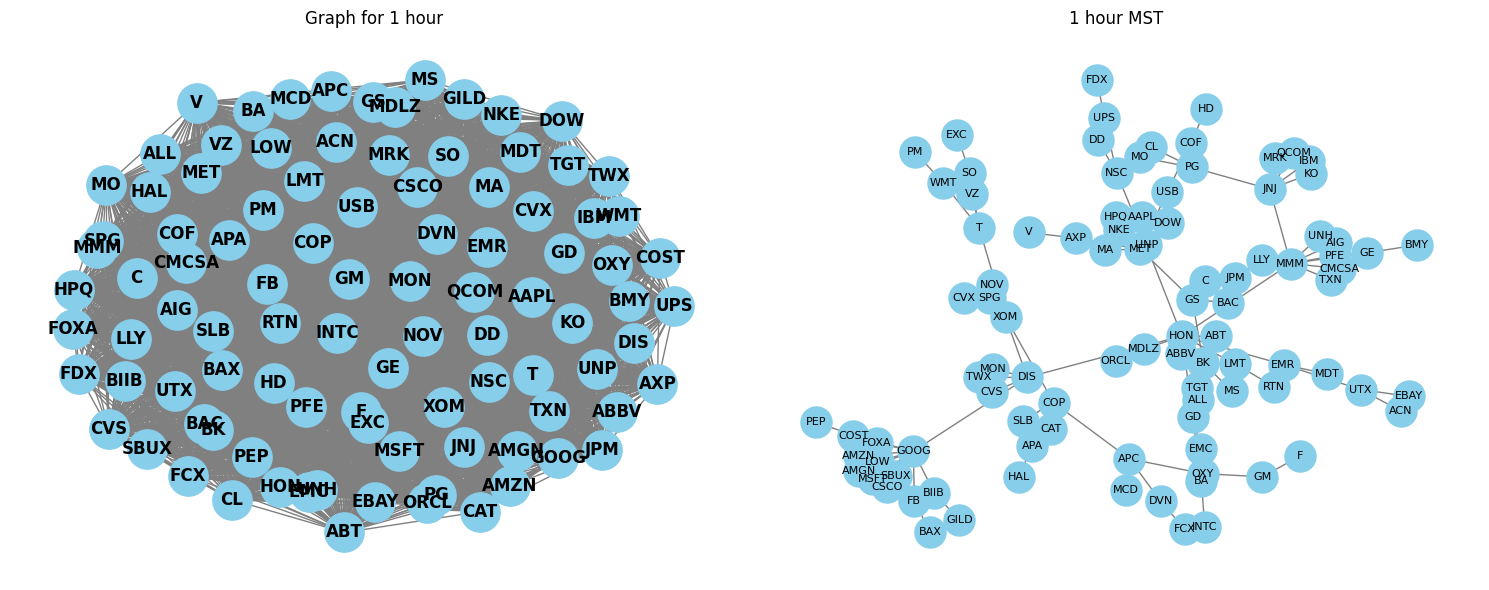

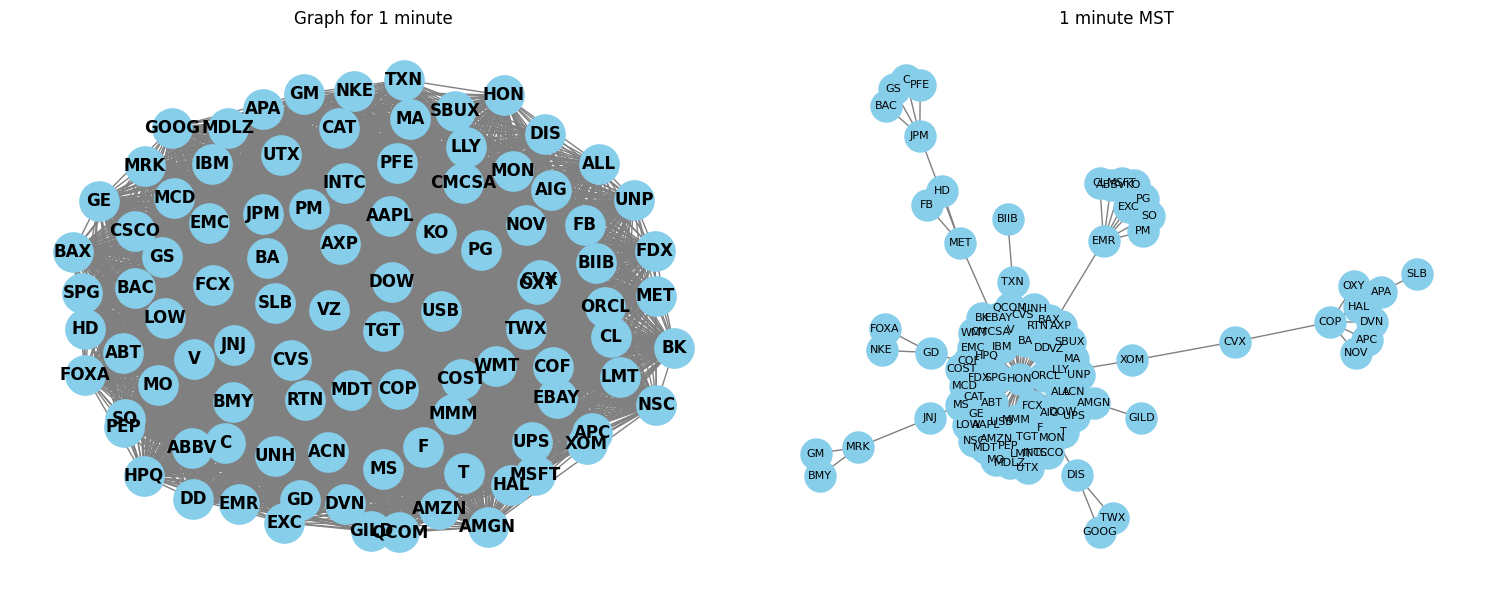

In [173]:
# Show it graphically

# Make MSTs (Cheapest Path to each node)
mst_1h = nx.minimum_spanning_tree(G_1h)

# Subplot for 1h
plt.figure(figsize=(15, 6))

# Plot the G_1h 
plt.subplot(1, 2, 1)
pos = nx.spring_layout(G_1h)  # You can choose a different layout if needed
nx.draw(G_1h, pos, with_labels=True, node_size=800, node_color='skyblue', font_weight='bold', edge_color='gray')
plt.title('Graph for 1 hour')

# Plot the mst_1h
plt.subplot(1, 2, 2)
pos = nx.spring_layout(mst_1h)  # You can use different layout algorithms
nx.draw(mst_1h, pos, with_labels=True, font_size=8, font_color='black', node_size=500, node_color='skyblue', edge_color='gray')
plt.title('1 hour MST')

plt.tight_layout()
plt.show()



# Make MSTs (Cheapest Path to each node)
mst_1m = nx.minimum_spanning_tree(G_1m)

# Subplot for 1h
plt.figure(figsize=(15, 6))

# Plot the G_1m
plt.subplot(1, 2, 1)
pos = nx.spring_layout(G_1m)  # You can choose a different layout if needed
nx.draw(G_1m, pos, with_labels=True, node_size=800, node_color='skyblue', font_weight='bold', edge_color='gray')
plt.title('Graph for 1 minute')

# Plot the mst_1h
plt.subplot(1, 2, 2)
pos = nx.spring_layout(mst_1m)  # You can use different layout algorithms
nx.draw(mst_1m, pos, with_labels=True, font_size=8, font_color='black', node_size=500, node_color='skyblue', edge_color='gray')
plt.title('1 minute MST')

plt.tight_layout()
plt.show()


In [174]:
# Print Result

# Compute degree distributions
degree_distribution_1h = dict(mst_1h.degree())
degree_distribution_1m = dict(mst_1m.degree())

# Sort the degree distribution (dict) after descending values
sorted_dict_desc_1h = dict(sorted(degree_distribution_1h.items(), key=lambda item: item[1], reverse=True))
sorted_dict_desc_1m = dict(sorted(degree_distribution_1m.items(), key=lambda item: item[1], reverse=True))

# Print Result
print("Top 5 stocks with highest degree in 1 hour MST:", list(sorted_dict_desc_1h.keys())[:5])
print("Top 5 stocks with highest degree in 1 minute MST:", list(sorted_dict_desc_1m.keys())[:5])

Top 5 stocks with highest degree in 1 hour MST: ['GOOG', 'HON', 'MMM', 'UNP', 'DIS']
Top 5 stocks with highest degree in 1 minute MST: ['HON', 'EMR', 'COP', 'JPM', 'MET']


## 3. Plot the degree distributions at 1 minute and 1 hour. Are the degree distributions qualitatively the same? Provide a comment to explain eventual similarities or dissimilarities.

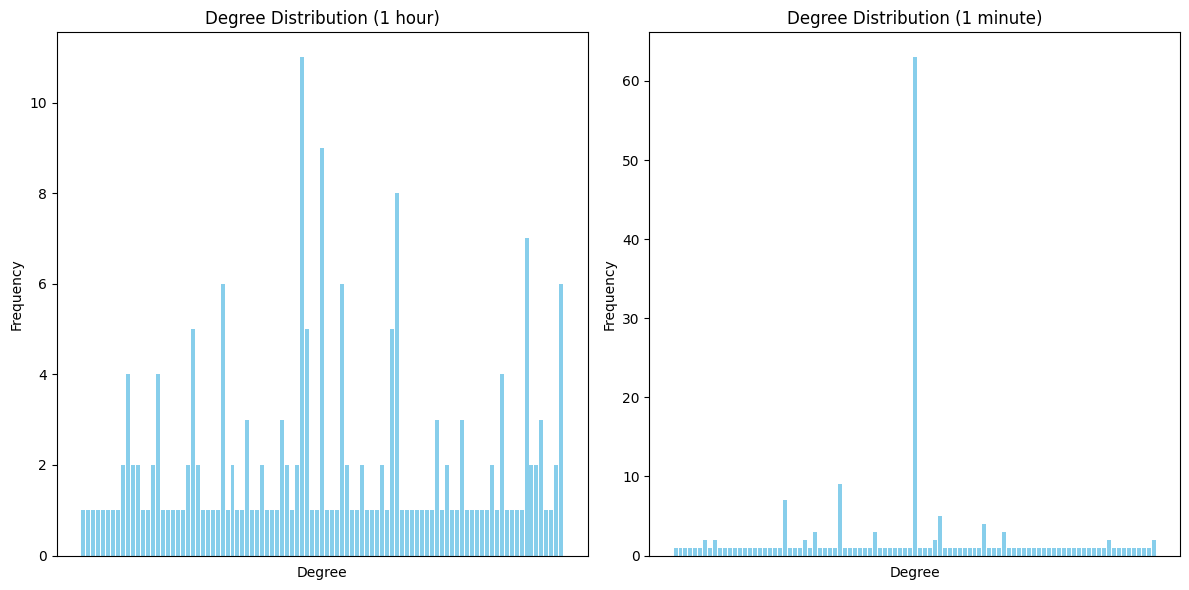

Sorted Dict which shows which node has which degree:
{'GOOG': 11, 'HON': 9, 'MMM': 8, 'UNP': 7, 'DIS': 6, 'JNJ': 6, 'XOM': 6, 'COP': 5, 'GS': 5, 'MET': 5, 'APC': 4, 'BK': 4, 'T': 4, 'EMR': 3, 'GD': 3, 'NSC': 3, 'PG': 3, 'UTX': 3, 'APA': 2, 'AXP': 2, 'BA': 2, 'BIIB': 2, 'COF': 2, 'COST': 2, 'DVN': 2, 'FB': 2, 'GE': 2, 'GM': 2, 'JPM': 2, 'LMT': 2, 'MDLZ': 2, 'OXY': 2, 'SO': 2, 'UPS': 2, 'USB': 2, 'WMT': 2, 'AAPL': 1, 'ABBV': 1, 'ABT': 1, 'ACN': 1, 'AIG': 1, 'ALL': 1, 'AMGN': 1, 'AMZN': 1, 'BAC': 1, 'BAX': 1, 'BMY': 1, 'C': 1, 'CAT': 1, 'CL': 1, 'CMCSA': 1, 'CSCO': 1, 'CVS': 1, 'CVX': 1, 'DD': 1, 'DOW': 1, 'EBAY': 1, 'EMC': 1, 'EXC': 1, 'F': 1, 'FCX': 1, 'FDX': 1, 'FOXA': 1, 'GILD': 1, 'HAL': 1, 'HD': 1, 'HPQ': 1, 'IBM': 1, 'INTC': 1, 'KO': 1, 'LLY': 1, 'LOW': 1, 'MA': 1, 'MCD': 1, 'MDT': 1, 'MO': 1, 'MON': 1, 'MRK': 1, 'MS': 1, 'MSFT': 1, 'NKE': 1, 'NOV': 1, 'ORCL': 1, 'PEP': 1, 'PFE': 1, 'PM': 1, 'QCOM': 1, 'RTN': 1, 'SBUX': 1, 'SLB': 1, 'SPG': 1, 'TGT': 1, 'TWX': 1, 'TXN': 1, 'UNH': 1,

In [175]:
# Plot degree distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(degree_distribution_1h.keys(), degree_distribution_1h.values(), color='skyblue')
plt.title('Degree Distribution (1 hour)')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.xticks([])  # Remove x-axis labels

plt.subplot(1, 2, 2)
plt.bar(degree_distribution_1m.keys(), degree_distribution_1m.values(), color='skyblue')
plt.title('Degree Distribution (1 minute)')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.xticks([])  # Remove x-axis labels

plt.tight_layout()
plt.show()

print("Sorted Dict which shows which node has which degree:")
print(sorted_dict_desc_1h)
print(sorted_dict_desc_1m)

Similarities: Both have a solid baseline of degree 1.

Dissimilarities: The minute degree plot has one clear maximum (HON) whereas the hour plot has various stocks with values over the baseline.

## 4. Compare the MST degree distributions of the 1 hour, 1 minute, Normal and One-Factor correlations: for each time scale, plot the three different distributions on the same plot. Is the degree distribution of MSTs well reproduced by the null Gaussian and One-Factor models?


In [176]:
len(arrays_nyse["cormat_gaussian_1h"])


97

In [177]:
# Same as in 2.3 but in a function
def calculate_degree_distribution(data):
    G = nx.Graph()

    G.add_nodes_from(tickers)

    nx.set_node_attributes(G, tickers_dict, name='ticker')

    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            weight = data[i][j]
            G.add_edge(tickers[i], tickers[j], weight=weight)

    mst = nx.minimum_spanning_tree(G)

    degree_distribution = dict(mst.degree())

    return degree_distribution

In [178]:
degree_distribution_gaussian_1h = calculate_degree_distribution(arrays_nyse["cormat_gaussian_1h"])
degree_distribution_gaussian_1m = calculate_degree_distribution(arrays_nyse["cormat_gaussian_1m"])
degree_distribution_onefactor_1h = calculate_degree_distribution(arrays_nyse["cormat_onefactor_1h"])
degree_distribution_onefactor_1m = calculate_degree_distribution(arrays_nyse["cormat_onefactor_1m"])

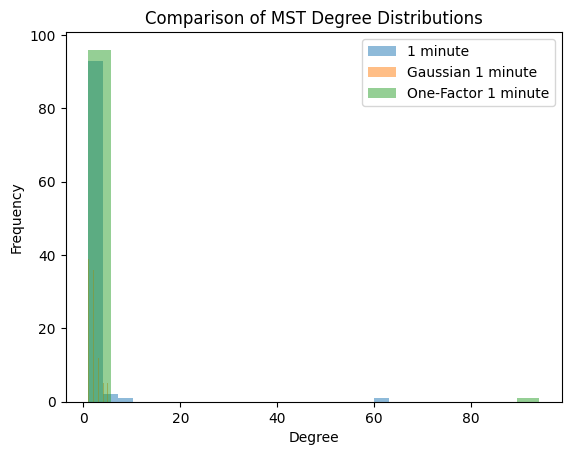

In [181]:

def plot_degree_distribution(degree_distribution, label):
    plt.hist(list(degree_distribution.values()), bins=20, alpha=0.5, label=label)

# Plot the degree distributions
plot_degree_distribution(degree_distribution_1m, '1 minute')
plot_degree_distribution(degree_distribution_gaussian_1m, 'Gaussian 1 minute')
plot_degree_distribution(degree_distribution_onefactor_1m, 'One-Factor 1 minute')

# Add labels and legend
plt.legend()
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Comparison of MST Degree Distributions')
plt.show()

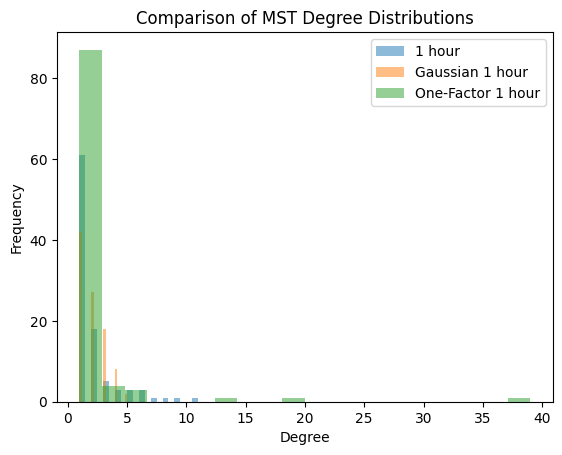

In [182]:

def plot_degree_distribution(degree_distribution, label):
    plt.hist(list(degree_distribution.values()), bins=20, alpha=0.5, label=label)

# Plot the degree distributions
plot_degree_distribution(degree_distribution_1h, '1 hour')
plot_degree_distribution(degree_distribution_gaussian_1h, 'Gaussian 1 hour')
plot_degree_distribution(degree_distribution_onefactor_1h, 'One-Factor 1 hour')

# Add labels and legend
plt.legend()
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Comparison of MST Degree Distributions')
plt.show()

In [180]:
print(dict(sorted(degree_distribution_1h.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_1m.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_onefactor_1h.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_onefactor_1m.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_gaussian_1h.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_gaussian_1m.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_onefactor_1h.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_onefactor_1m.items(), key=lambda item: item[1], reverse=True)))

{'GOOG': 11, 'HON': 9, 'MMM': 8, 'UNP': 7, 'DIS': 6, 'JNJ': 6, 'XOM': 6, 'COP': 5, 'GS': 5, 'MET': 5, 'APC': 4, 'BK': 4, 'T': 4, 'EMR': 3, 'GD': 3, 'NSC': 3, 'PG': 3, 'UTX': 3, 'APA': 2, 'AXP': 2, 'BA': 2, 'BIIB': 2, 'COF': 2, 'COST': 2, 'DVN': 2, 'FB': 2, 'GE': 2, 'GM': 2, 'JPM': 2, 'LMT': 2, 'MDLZ': 2, 'OXY': 2, 'SO': 2, 'UPS': 2, 'USB': 2, 'WMT': 2, 'AAPL': 1, 'ABBV': 1, 'ABT': 1, 'ACN': 1, 'AIG': 1, 'ALL': 1, 'AMGN': 1, 'AMZN': 1, 'BAC': 1, 'BAX': 1, 'BMY': 1, 'C': 1, 'CAT': 1, 'CL': 1, 'CMCSA': 1, 'CSCO': 1, 'CVS': 1, 'CVX': 1, 'DD': 1, 'DOW': 1, 'EBAY': 1, 'EMC': 1, 'EXC': 1, 'F': 1, 'FCX': 1, 'FDX': 1, 'FOXA': 1, 'GILD': 1, 'HAL': 1, 'HD': 1, 'HPQ': 1, 'IBM': 1, 'INTC': 1, 'KO': 1, 'LLY': 1, 'LOW': 1, 'MA': 1, 'MCD': 1, 'MDT': 1, 'MO': 1, 'MON': 1, 'MRK': 1, 'MS': 1, 'MSFT': 1, 'NKE': 1, 'NOV': 1, 'ORCL': 1, 'PEP': 1, 'PFE': 1, 'PM': 1, 'QCOM': 1, 'RTN': 1, 'SBUX': 1, 'SLB': 1, 'SPG': 1, 'TGT': 1, 'TWX': 1, 'TXN': 1, 'UNH': 1, 'V': 1, 'VZ': 1}
{'HON': 63, 'EMR': 9, 'COP': 7, 'JP

Yes they are relativly similar. But we can see thaton both plots (hour and minute) the OneFactor has a more extended tail than the empiric one. Also the Gaussian is shorter than the other ones. However they have the same structure!

Creating Results:
`jupyter nbconvert Assignment_03.ipynb --to pdf --output Assignment_03_Results-T2.pdf`